## 의료데이터를 활용한 분류 모델 생성
- 환자의 의료기록을 전제한 생존,죽음 분류 모델

In [119]:
#데이터 로드
import pandas as pd
import numpy as np
df =pd.read_csv('./heart_failure_clinical_records_dataset.csv', encoding='cp949')

In [2]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 데이터 전처리
1. 데이터 결측치 및 타입 확인
2.데이터 유형 분류 - 범주형, 연속형, 시간형
3. 데이터 이상치 확인 - IQR 방법 

In [3]:
#결측치 및 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
#결측치 확인
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'anaemia'}>,
        <Axes: title={'center': 'creatinine_phosphokinase'}>,
        <Axes: title={'center': 'diabetes'}>],
       [<Axes: title={'center': 'ejection_fraction'}>,
        <Axes: title={'center': 'high_blood_pressure'}>,
        <Axes: title={'center': 'platelets'}>,
        <Axes: title={'center': 'serum_creatinine'}>],
       [<Axes: title={'center': 'serum_sodium'}>,
        <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'smoking'}>,
        <Axes: title={'center': 'time'}>],
       [<Axes: title={'center': 'DEATH_EVENT'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

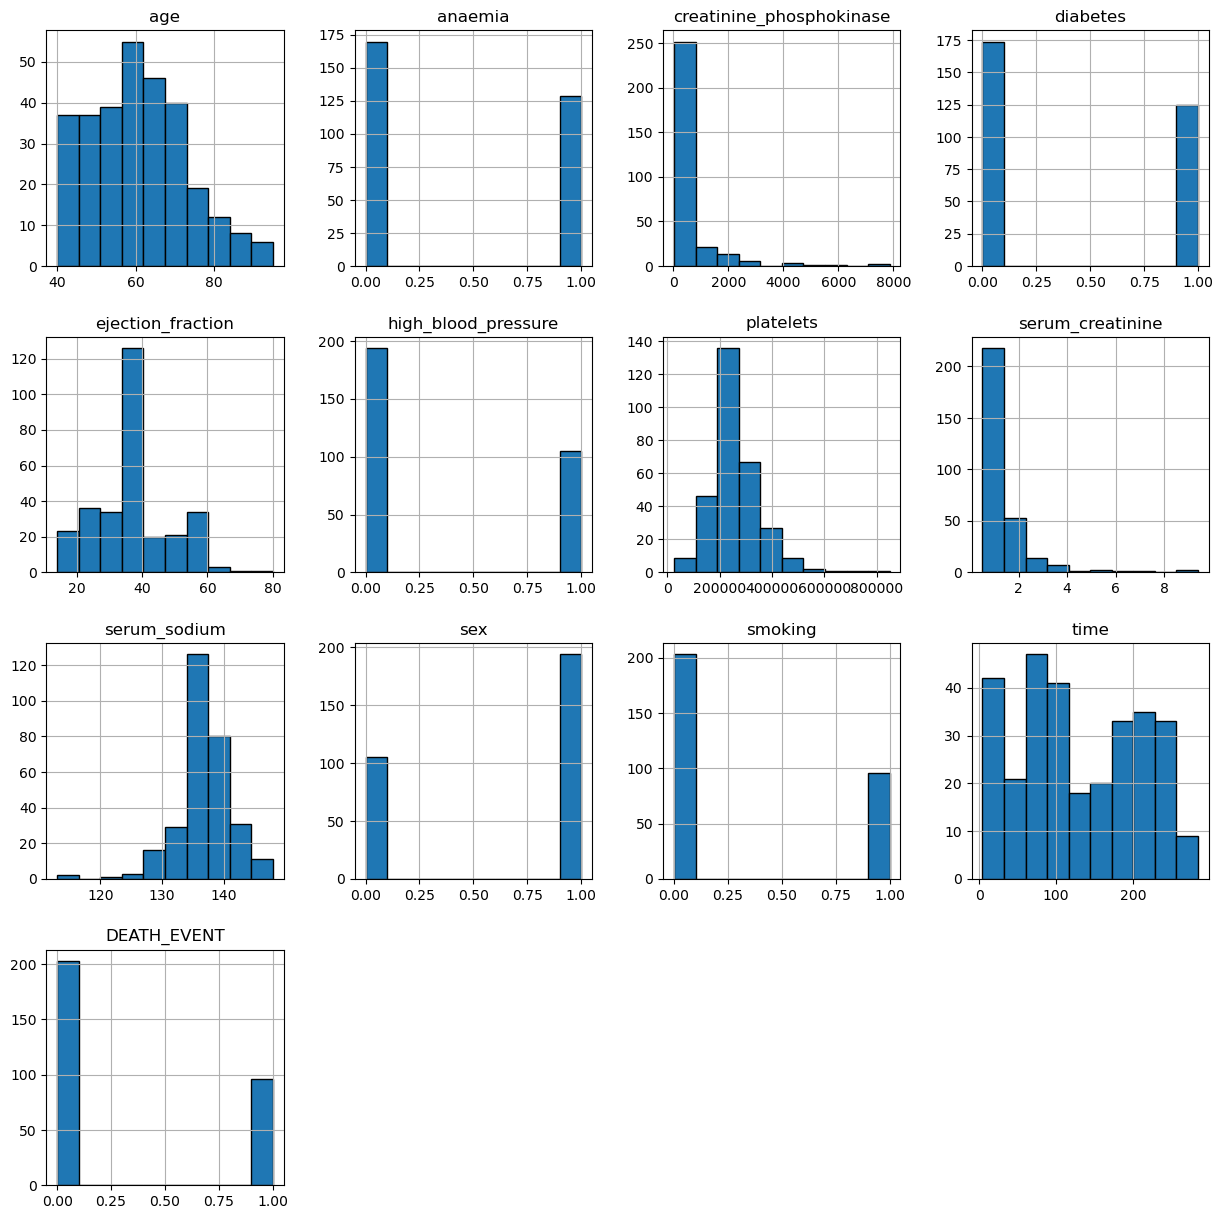

In [6]:
df.hist(figsize=(15,15), edgecolor='black')

<Axes: >

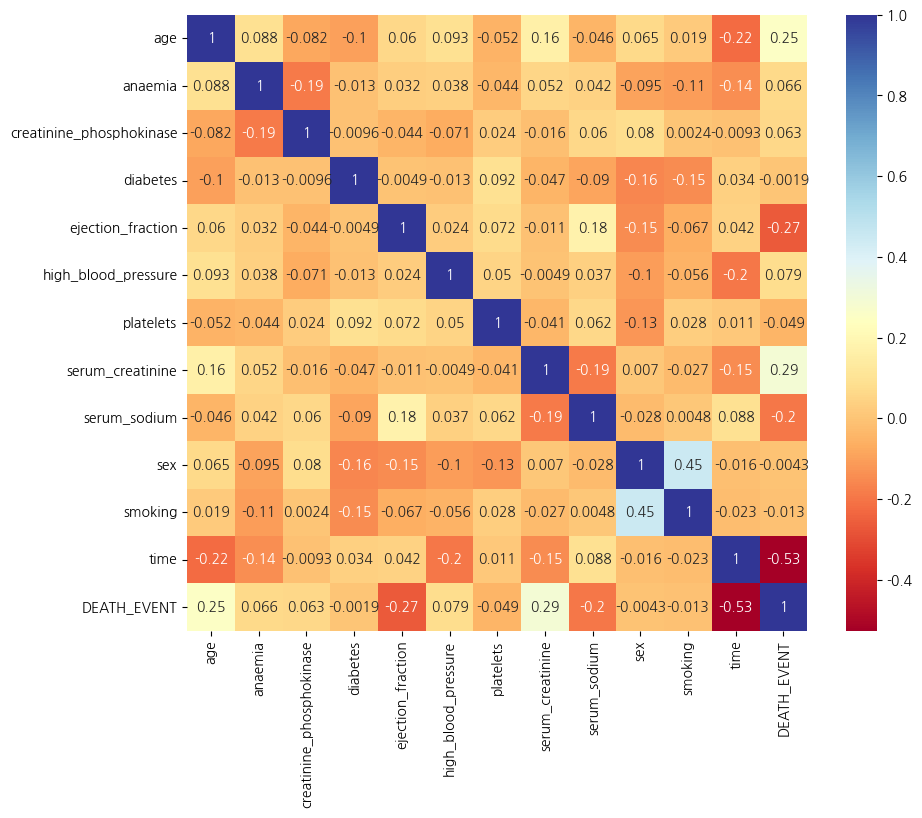

In [179]:
#독립변수의 상관계수 확인
import matplotlib.pyplot as plt
import seaborn as sns

corrmat = df.corr()
plt.subplots(figsize=(10,8))
sns.heatmap(corrmat,cmap='RdYlBu', annot=True)

In [8]:
#DEATH_EVENT 상관관계 정렬
death_cormat = corrmat['DEATH_EVENT']
sorted_death_cormat = death_cormat.sort_values(ascending=False)
sorted_death_cormat

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64

In [9]:
#상관관계 출력 (절댓값 사용)

sorted_death_cormat = sorted_death_cormat.abs().sort_values(ascending=False)
sorted_death_cormat

DEATH_EVENT                 1.000000
time                        0.526964
serum_creatinine            0.294278
ejection_fraction           0.268603
age                         0.253729
serum_sodium                0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
platelets                   0.049139
smoking                     0.012623
sex                         0.004316
diabetes                    0.001943
Name: DEATH_EVENT, dtype: float64

## 상관계수 0.1 이상의 독립변수 선택
- 사망&생존과 연관있는 독립변수들로 시각화 진행

In [10]:
#상관관계 0.1 이상의 독립변수 선택
filterd_cormat = sorted_death_cormat[sorted_death_cormat > 0.1]
filterd_cormat

DEATH_EVENT          1.000000
time                 0.526964
serum_creatinine     0.294278
ejection_fraction    0.268603
age                  0.253729
serum_sodium         0.195204
Name: DEATH_EVENT, dtype: float64

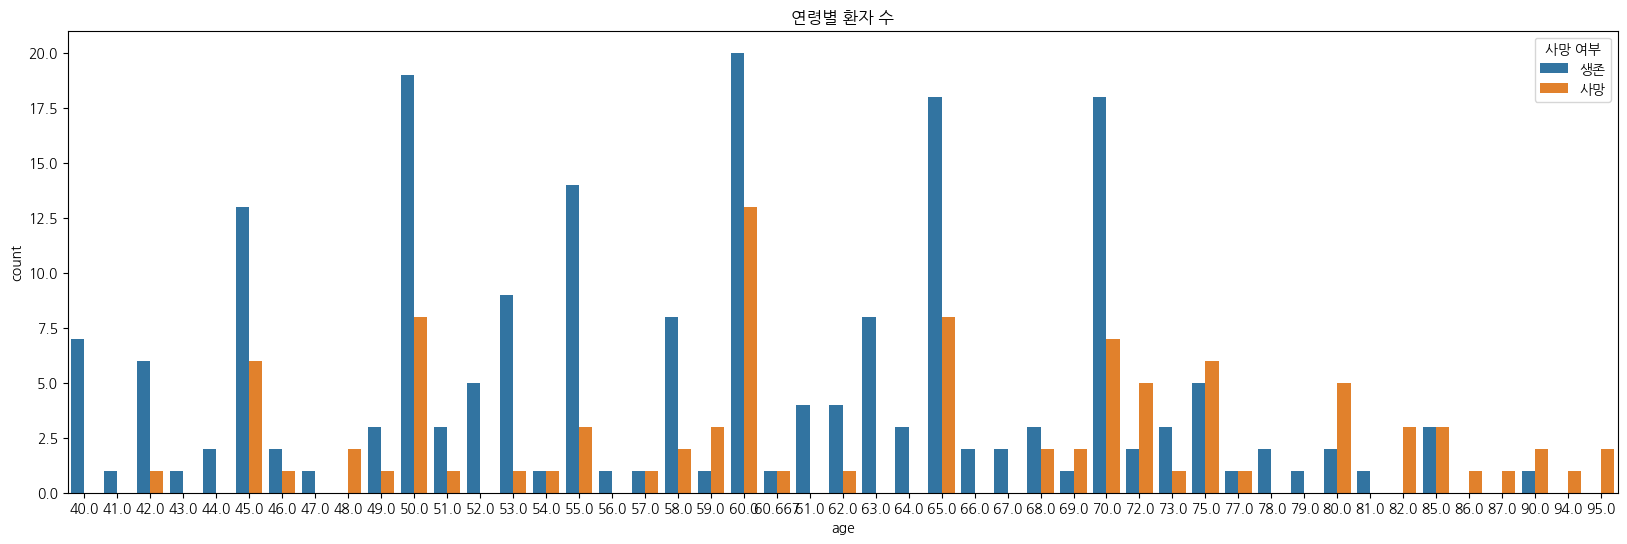

In [178]:
#나이대별 생존, 사망 확인
#한글 폰트 적용
import matplotlib
plt.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(20,6))
ax= sns.countplot(x='age', data=df, hue='DEATH_EVENT')

#범례 수정
handles, label = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['생존','사망'], title='사망 여부')
plt.title('연령별 환자 수')
plt.show()

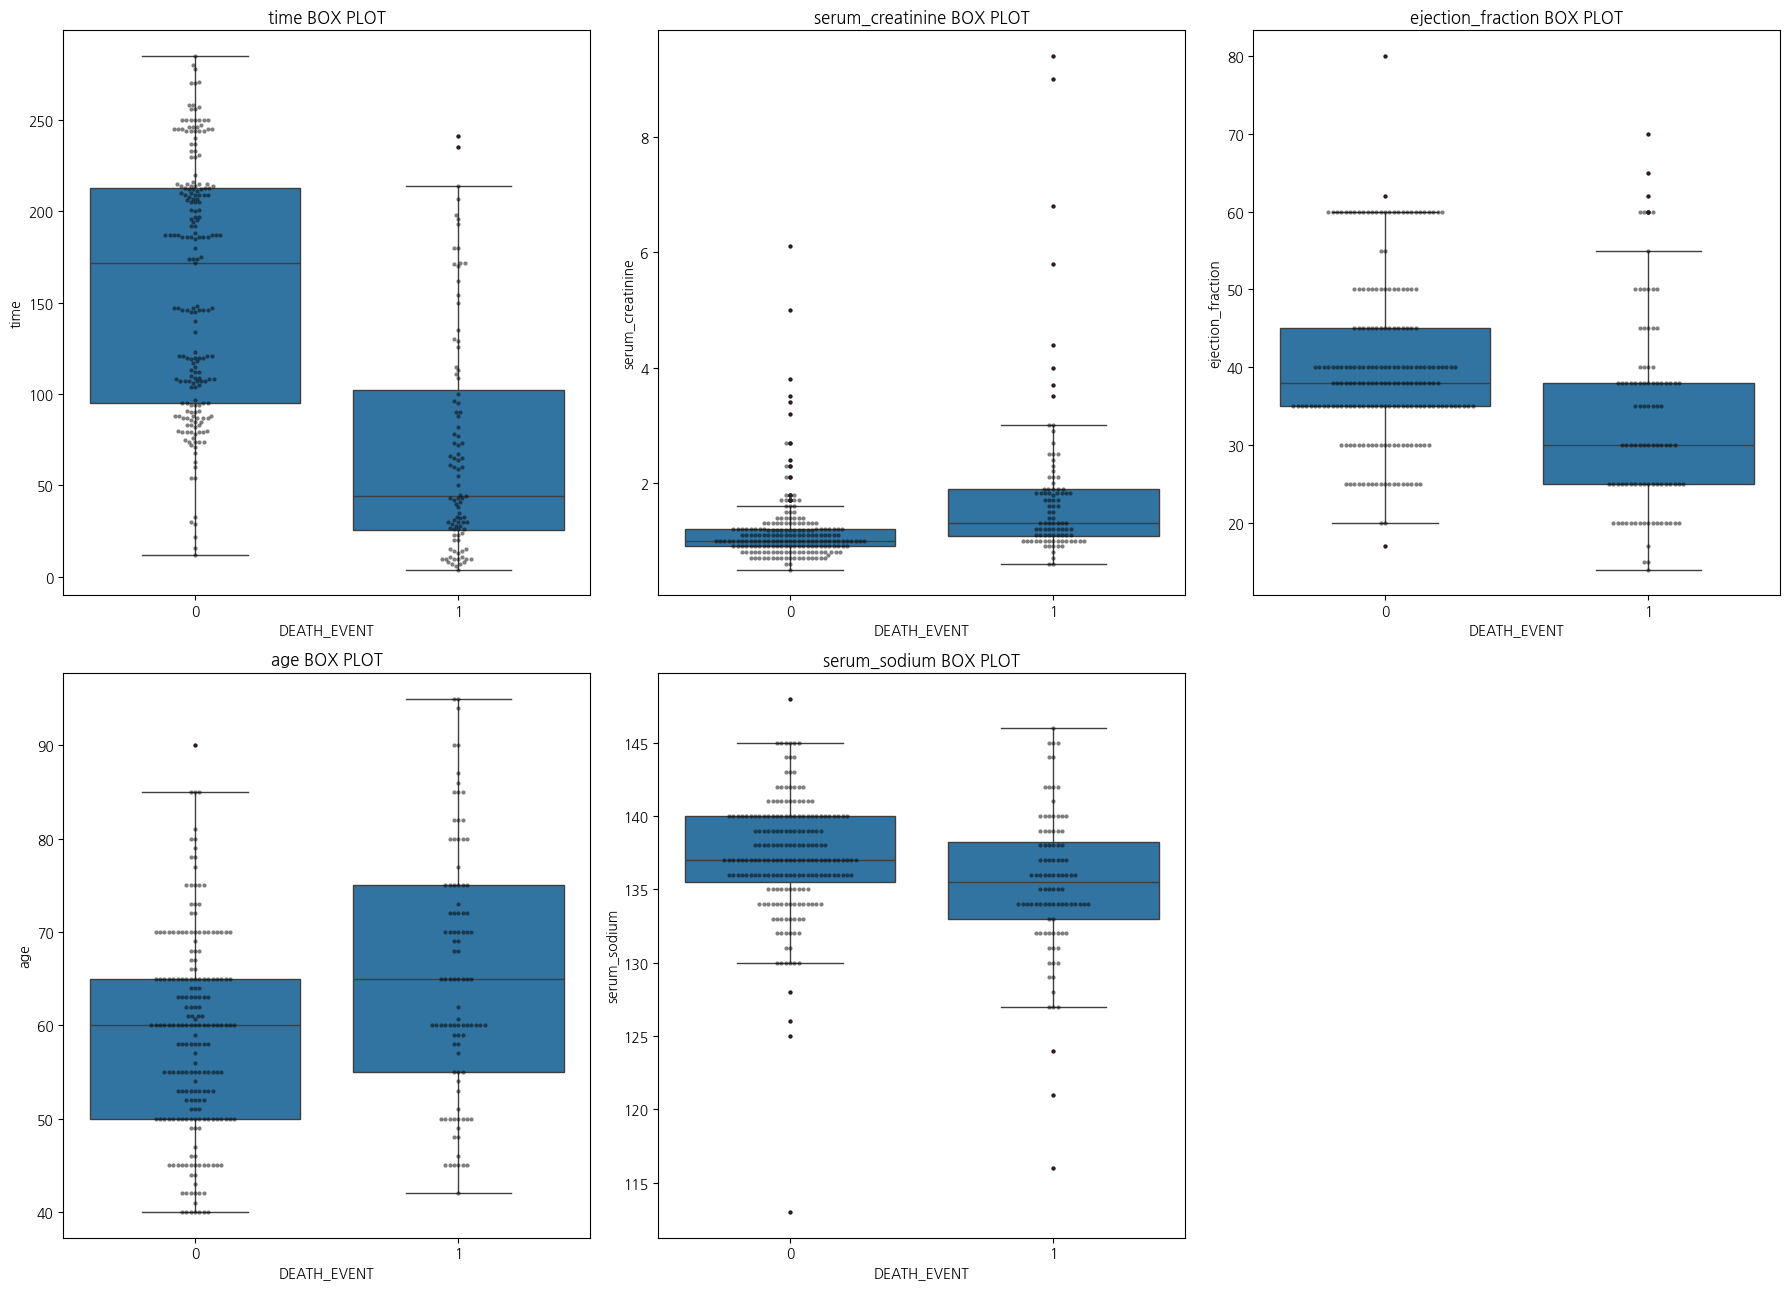

In [133]:
#boxplot으로 이상치, swarmplot으로 데이터의 분포 확인
#상관계수 0.1이상 독립변수들
# 상관계수 0.1 이상 독립변수들
filtered_cormat = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium'] 

# 하나의 큰 figure에 2행 3열의 subplot 구성
plt.figure(figsize=(18, 13)) 

for i, feature in enumerate(filtered_cormat):
    plt.subplot(2, 3, i + 1)  # 2행 3열의 서브플롯에서 i+1번째 위치
    sns.swarmplot(x=df['DEATH_EVENT'], y=df[feature], color='black', alpha=0.5, size=3)
    sns.boxplot(x=df['DEATH_EVENT'], y=df[feature], flierprops=dict(marker='o', markerfacecolor='red', markersize=2))
    plt.title(f'{feature} BOX PLOT')
    plt.xlabel('DEATH_EVENT')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()



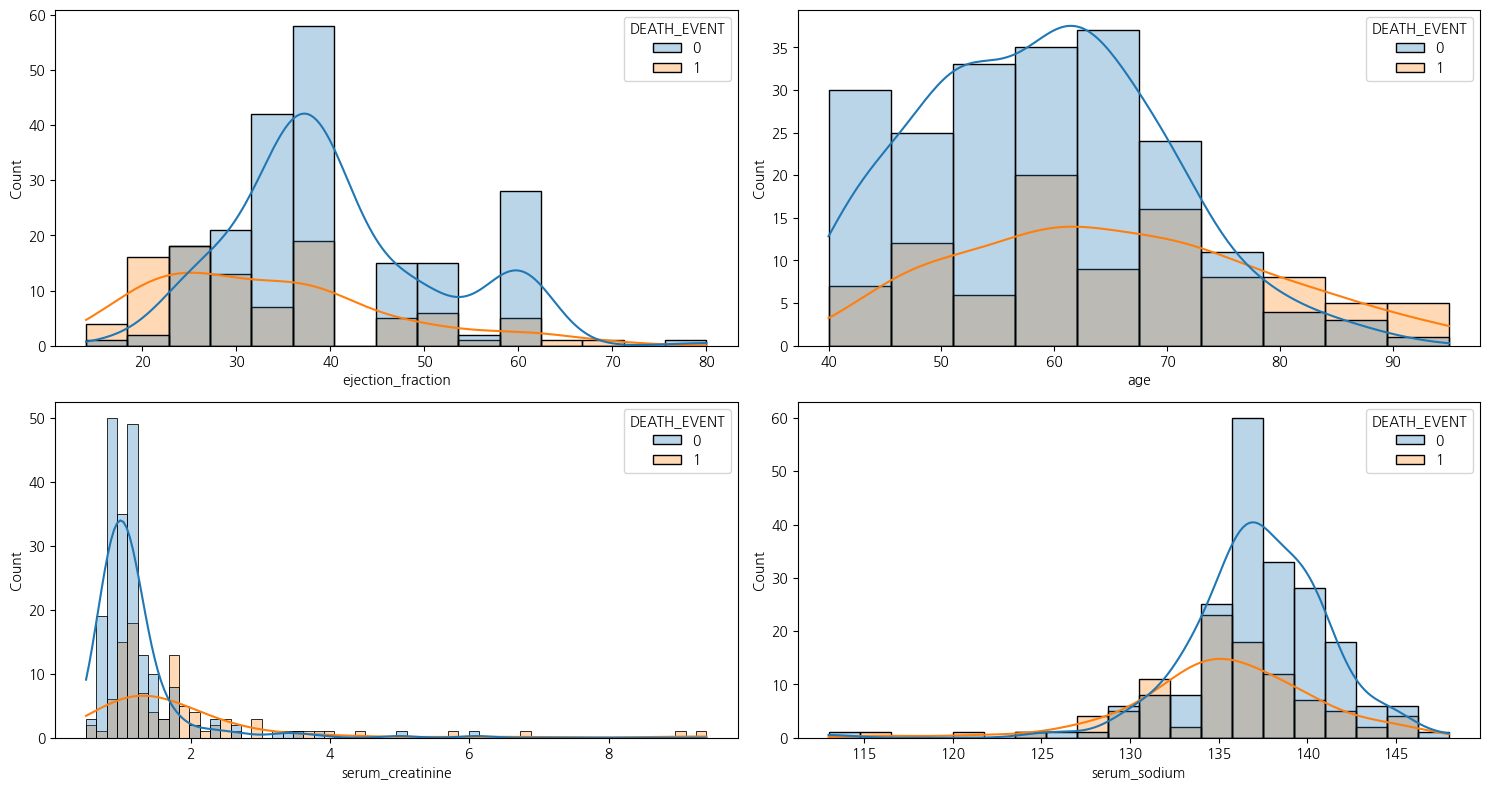

In [110]:
#상관계수 0.1이상 독립변수들
filtered_cormat = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium'] 

plt.figure(figsize=(15,8))
plt.subplot(2,2,1)
sns.histplot(x='ejection_fraction', data=df, hue='DEATH_EVENT', kde=True, alpha=0.3)
plt.subplot(2,2,2)
sns.histplot(x='age', data=df, hue='DEATH_EVENT', kde=True, alpha=0.3)
plt.subplot(2,2,3)
sns.histplot(x='serum_creatinine', data=df, hue='DEATH_EVENT', kde=True, alpha=0.3)
plt.subplot(2,2,4)
sns.histplot(x='serum_sodium', data=df, hue='DEATH_EVENT', kde=True, alpha=0.3)


plt.tight_layout()
plt.show()

In [73]:
#데이터 이상치 확인 - IQR 방법
#상관계수가 0.1이상인 독립변수들
filtered_cormat = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium'] 
for feature in filterd_cormat:
  Q1 = df[feature].quantile(0.25)
  Q3 = df[feature].quantile(0.75)
  
  IQR = Q3 -Q1
  lower_bound = Q1 - (IQR * 1.5)
  upper_bound = Q3 + (IQR * 1.5)
  
  outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound) ]
  print(f'{feature}의 이상치 개수 : {len(outliers)}')


time의 이상치 개수 : 0
serum_creatinine의 이상치 개수 : 29
ejection_fraction의 이상치 개수 : 2
age의 이상치 개수 : 0
serum_sodium의 이상치 개수 : 4


In [ ]:
from scipy import stats

#상관계수 0.1이상의 독립변수들
filtered_cormat = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium'] 

#독립변수 별 사망,생존 데이터 분리
for feature in filtered_cormat:
	survived = df[df['DEATH_EVENT']==0][feature]
	died = df[df['DEATH_EVENT']==1][feature]
	# 정규성 검정
	print(f"{feature} 생존 그룹 정규성 검정:", stats.shapiro(survived))
	print(f"{feature} 사망 그룹 정규성 검정:", stats.shapiro(died))
	print('-'*30)


time 생존 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.9422173819111933), pvalue=np.float64(3.0204162394474257e-07))
time 사망 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.8623124146846828), pvalue=np.float64(5.631672087249483e-08))
------------------------------
serum_creatinine 생존 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.5886271765340354), pvalue=np.float64(9.584146505428874e-22))
serum_creatinine 사망 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.6084221177814022), pvalue=np.float64(1.2830925518875242e-14))
------------------------------
ejection_fraction 생존 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.9199300170176953), pvalue=np.float64(4.7048493514919614e-09))
ejection_fraction 사망 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.9265494833182164), pvalue=np.float64(4.53496605089971e-05))
------------------------------
age 생존 그룹 정규성 검정: ShapiroResult(statistic=np.float64(0.9796409588380118), pvalue=np.float64(0.004827620364551143))
age 사망 그룹 정규성 검정: ShapiroResult(statis

### 정규성 검정 결과 p값이 0.05보다 작아 정규성 가정을 만족하지X
- 비모수 검정 진행

In [120]:
# 비모수 검정 수행
print("=== Mann-Whitney U 검정 결과 ===")
for feature in filtered_cormat:
    survived = df[df['DEATH_EVENT']==0][feature]
    died = df[df['DEATH_EVENT']==1][feature]
    
    # Mann-Whitney U 검정
    u_stat, p_value = stats.mannwhitneyu(survived, died)
    
    # 효과 크기 계산 (r = Z / sqrt(N))
    n1, n2 = len(survived), len(died)
    z_score = (u_stat - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)
    effect_size = abs(z_score) / np.sqrt(n1 + n2)
    
    print(f"{feature}:")
    print(f"  U-통계량: {u_stat:.1f}, p-값: {p_value:.10f}")
    print(f"  효과 크기(r): {effect_size:.4f}")
    
    # 결과 해석
    if p_value <= 0.05:
        print(f"  결론: {feature}는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.")
    else:
        print(f"  결론: {feature}는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 없습니다.")
    print('-'*30)

=== Mann-Whitney U 검정 결과 ===
time:
  U-통계량: 16288.5, p-값: 0.0000000000
  효과 크기(r): 0.5422
  결론: time는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.
------------------------------
serum_creatinine:
  U-통계량: 5298.0, p-값: 0.0000000002
  효과 크기(r): 0.3684
  결론: serum_creatinine는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.
------------------------------
ejection_fraction:
  U-통계량: 13176.5, p-값: 0.0000007368
  효과 크기(r): 0.2844
  결론: ejection_fraction는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.
------------------------------
age:
  U-통계량: 7121.0, p-값: 0.0001667518
  효과 크기(r): 0.2173
  결론: age는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.
------------------------------
serum_sodium:
  U-통계량: 12261.5, p-값: 0.0002927557
  효과 크기(r): 0.2086
  결론: serum_sodium는 생존 그룹과 사망 그룹 간에 통계적으로 유의한 차이가 있습니다.
------------------------------


## 데이터 스플릿

In [173]:
from sklearn.model_selection import train_test_split

test_data = df[filtered_cormat]
target = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(test_data, target, test_size=0.2, random_state=225, stratify=target)


In [174]:
## 데이터 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

오차행렬 
 [[38  3]
 [ 7 12]]
--------------------
정확도 = 0.8333333333333334
F1 점수: 0.7059
분류 보고서:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



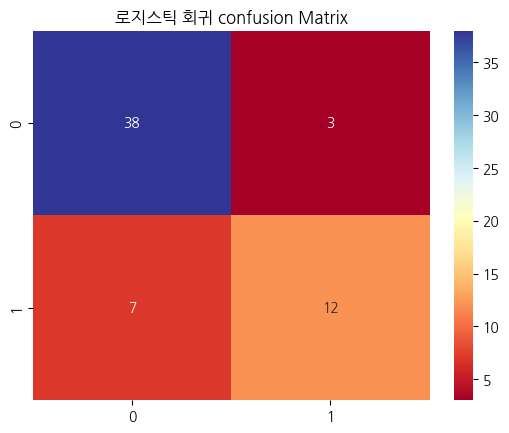

In [322]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score,classification_report

model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c_mat = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred)


print(f'오차행렬 \n {c_mat}')
print('-'*20)
print(f'정확도 = {accuracy}')
print(f"F1 점수: {f1:.4f}")
print("분류 보고서:")
print(report)

sns.heatmap(c_mat, cmap = 'RdYlBu', annot=True)
plt.title('로지스틱 회귀 confusion Matrix')
plt.show()

## Logistic Regression Tunning[GridSearchCV]

Fitting 5 folds for each of 84 candidates, totalling 420 fits
최적 파라미터: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
최고 교차 검증 점수: 0.8368794326241135
테스트 세트 정확도: 0.8333333333333334
분류 보고서
              precision    recall  f1-score   support

           0       0.82      0.98      0.89        41
           1       0.91      0.53      0.67        19

    accuracy                           0.83        60
   macro avg       0.86      0.75      0.78        60
weighted avg       0.85      0.83      0.82        60



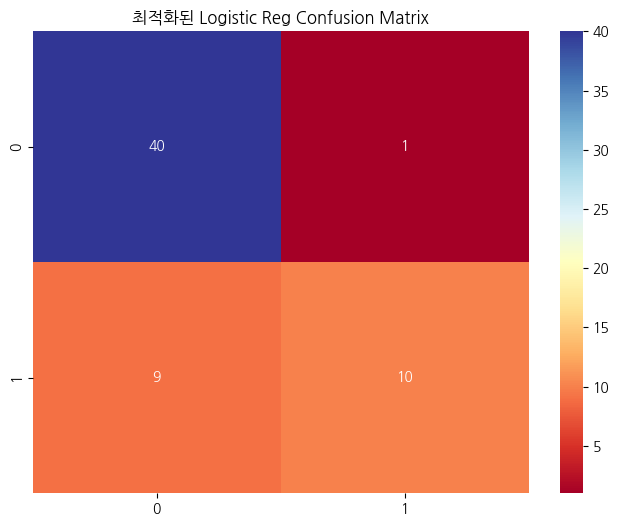

In [327]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

# 로지스틱 회귀 파라미터 그리드 정의
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100,200],
    'penalty': ['l1', 'l2', ],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000]
}

# 로지스틱 회귀 모델 초기화
lr_model = LogisticRegression(random_state=42)

# GridSearchCV 초기화
grid_search_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,  # 5-fold 교차 검증
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# GridSearchCV 학습
grid_search_lr.fit(X_train, y_train)

# 최적 파라미터와 점수 확인
print("최적 파라미터:", grid_search_lr.best_params_)
print("최고 교차 검증 점수:", grid_search_lr.best_score_)

# 테스트 세트에서 평가
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test)
c_mat_lr = confusion_matrix(y_test,y_pred_lr )
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report = classification_report(y_test,y_pred_lr )
print("테스트 세트 정확도:", accuracy_lr)
print("분류 보고서")
print(report)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(c_mat_lr, cmap='RdYlBu', annot=True)
plt.title('최적화된 Logistic Reg Confusion Matrix')
plt.show()



## Decision Tree Classifier

오차행렬 
 [[33  8]
 [ 8 11]]
--------------------
정확도 = 0.7333333333333333


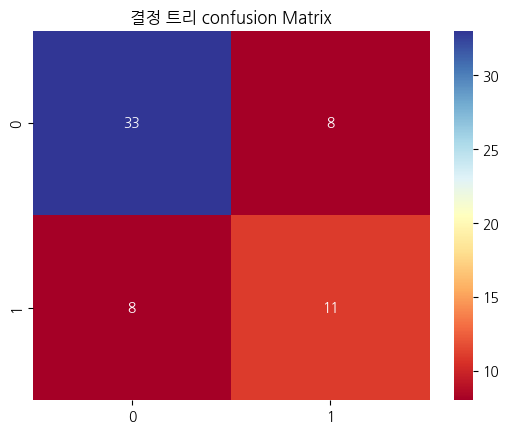

In [281]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

tree_model = DecisionTreeClassifier()

#모델 학습
tree_model.fit(X_train,y_train)

#예측 수행
tree_pred = tree_model.predict(X_test)

#성능 평가
c_mat_tree = confusion_matrix(y_test, tree_pred)
accuracy_tree = accuracy_score(y_test, tree_pred)

print(f'오차행렬 \n {c_mat_tree}')
print('-'*20)
print(f'정확도 = {accuracy_tree}')

sns.heatmap(c_mat_tree, cmap = 'RdYlBu', annot=True)
plt.title('결정 트리 confusion Matrix')
plt.show()

## Decision Tree Classifier Tunning[GridSearchCV]

Fitting 5 folds for each of 72 candidates, totalling 360 fits
최적 파라미터: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 4}
최고 교차 검증 점수: 0.8408687943262411
테스트 세트 정확도: 0.7833333333333333


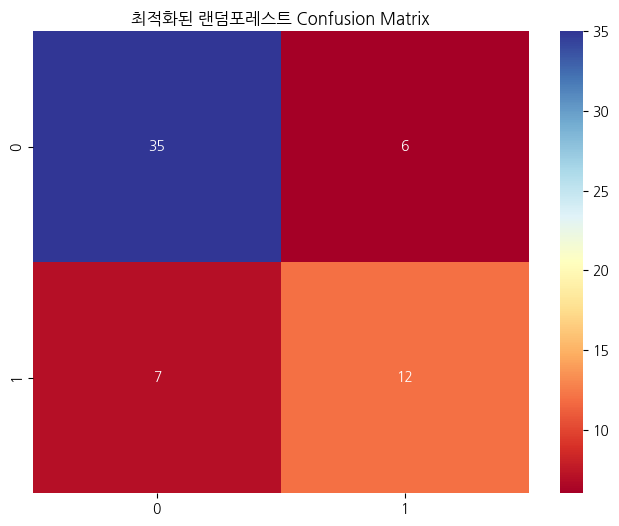

In [306]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 결정 트리 파라미터 그리드 정의
param_grid_dt = {
    'max_depth': [7, 10, 25, None],
    'min_samples_split': [4, 6, 10],
    'min_samples_leaf': [2, 4, 6],
    'criterion': ['gini', 'entropy']
}

# 결정 트리 모델 초기화
tree_model = DecisionTreeClassifier(random_state=56)

# GridSearchCV 초기화
grid_search_dt = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid_dt,
    cv=5,  # 5-fold 교차 검증
    scoring='accuracy',
    n_jobs=-1,  # 모든 CPU 코어 사용
    verbose=1
)

# GridSearchCV 학습
grid_search_dt.fit(X_train, y_train)

# 최적 파라미터와 점수 확인
print("최적 파라미터:", grid_search_dt.best_params_)
print("최고 교차 검증 점수:", grid_search_dt.best_score_)

# 테스트 세트에서 평가
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)
c_mat_dt = confusion_matrix(y_test,y_pred_dt)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("테스트 세트 정확도:", accuracy_dt)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(c_mat_dt, cmap='RdYlBu', annot=True)
plt.title('최적화된 랜덤포레스트 Confusion Matrix')
plt.show()


## Random Forest

오차행렬 
 [[38  3]
 [ 6 13]]
--------------------
정확도 = 0.85


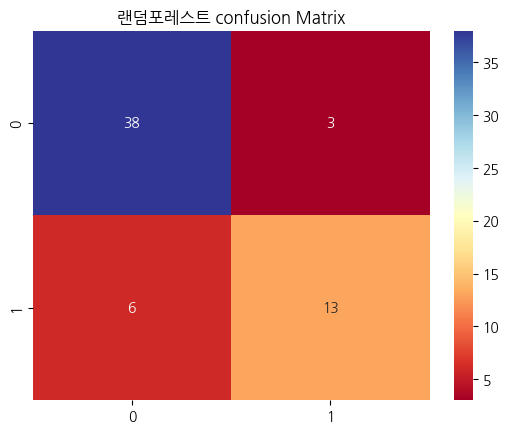

In [272]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

#모델 학습
rf_model.fit(X_train, y_train)

#예측 수행
rf_pred = rf_model.predict(X_test)

c_mat_rf = confusion_matrix(y_test, rf_pred)
accuracy_rf = accuracy_score(y_test, rf_pred)

print(f'오차행렬 \n {c_mat_rf}')
print('-'*20)
print(f'정확도 = {accuracy_rf}')

sns.heatmap(c_mat_rf, cmap = 'RdYlBu', annot=True)
plt.title('랜덤포레스트 confusion Matrix')
plt.show()


## Random Forest Tunning [GridSearchCV]

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
최적 하이퍼파라미터: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
최고 정확도: 0.8828900709219859


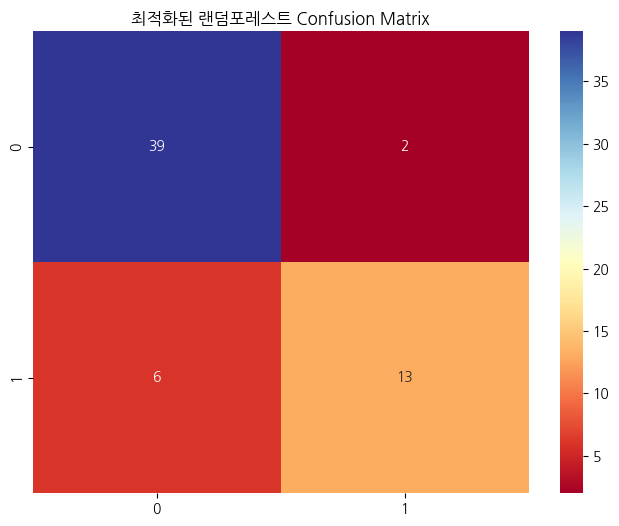

In [307]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [20, 35, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 모델 생성
randome_tree = RandomForestClassifier(random_state=42)

# GridSearchCV 객체 생성
grid_search = GridSearchCV(
    estimator=randome_tree,
    param_grid=param_grid,
    cv=5,                  # 5-fold 교차 검증
    scoring='accuracy',    # 최적화할 평가 지표
    n_jobs=-1,             # 모든 CPU 코어 사용
    verbose=1              # 진행 상황 출력
)

# 그리드 서치 수행
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 및 점수 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 정확도:", grid_search.best_score_)

# 최적 모델로 예측
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# 성능 평가
c_mat_rf = confusion_matrix(y_test, rf_pred)
accuracy_rf = accuracy_score(y_test, rf_pred)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(c_mat_rf, cmap='RdYlBu', annot=True)
plt.title('최적화된 랜덤포레스트 Confusion Matrix')
plt.show()